In [1]:
%pip install -q pandas numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
pd.set_option("display.max_columns",40)
np.random.seed(42)

In [3]:
df=sns.load_dataset("titanic")

In [4]:
df.shape

(891, 15)

In [5]:
nums_cols=["age","fare","sibsp","parch"]
print(nums_cols)
cats_cols=["survived","pclass","sex","embarked","class","who","alone"]
print(cats_cols)

['age', 'fare', 'sibsp', 'parch']
['survived', 'pclass', 'sex', 'embarked', 'class', 'who', 'alone']


In [6]:
df_nums=df[nums_cols]
df_cats=df[cats_cols] 

In [7]:
df_nums.head()

,age,fare,sibsp,parch
0,22.0,7.2500,1,0
1,38.0,71.2833,1,0
2,26.0,7.9250,0,0
3,35.0,53.1000,1,0
4,35.0,8.0500,0,0


## 3   Detect the outliers

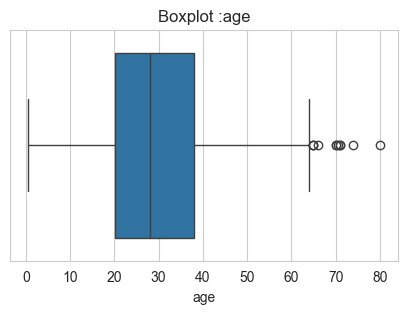

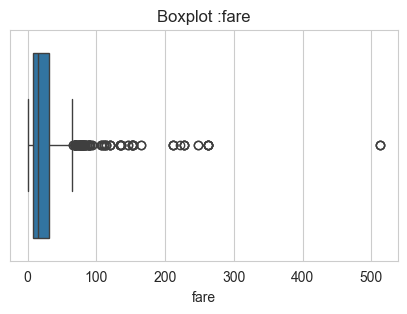

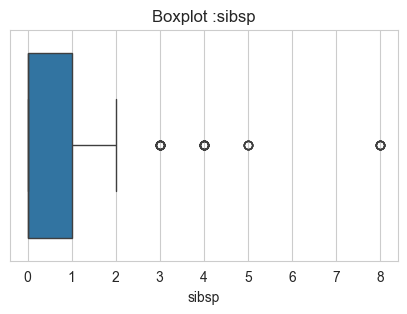

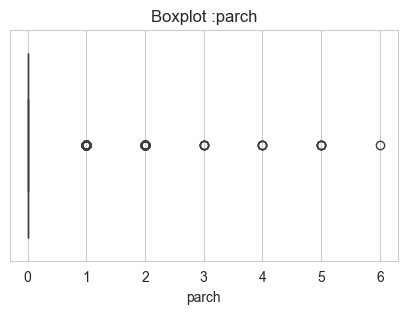

In [8]:
for col in nums_cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot :{col}")
    plt.xlabel(col)
    plt.show()

 ### IQR Method

In [9]:
def iqr_bounds(series,factor=1.5):
    q1=series.quantile(0.25)
    q3=series.quantile(0.75)
    iqr=q3-q1
    lower_bound=q1-factor*iqr  
    upper_bound=q3+factor*iqr
    return lower_bound,upper_bound,iqr

    

In [10]:
for col in nums_cols:
    clean_cols=df[nums_cols].dropna()
    lower,upper,iqr=iqr_bounds(clean_cols)
    outlier_mask=(clean_cols<lower) | (clean_cols>upper)
    num_outlier=outlier_mask.sum()
    total=num_outlier.shape[0]
    print(f"\nIQR method for {col}:")
    # print(f" Q1 - 1.5*IQR: {lower :. 2f}")
    # print(f" Q3 + 1.5*IQR: {upper :. 2f}")
    # print(f" IQR: {iqr :. 2f}")
    print(f" Outliers: {num_outlier} out of {total}")


IQR method for age:
 Outliers: age      11
fare     94
sibsp    35
parch    15
dtype: int64 out of 4

IQR method for fare:
 Outliers: age      11
fare     94
sibsp    35
parch    15
dtype: int64 out of 4

IQR method for sibsp:
 Outliers: age      11
fare     94
sibsp    35
parch    15
dtype: int64 out of 4

IQR method for parch:
 Outliers: age      11
fare     94
sibsp    35
parch    15
dtype: int64 out of 4


<b>5 z- score Method 

|z| =(value-mean)/std<br>

|z| >3 as outliers

In [11]:
z_threshold=3.0

for col in nums_cols:
    col_clean=df[nums_cols].dropna()
    mean=col_clean.mean()
    std=col_clean.std()
    
    z_score=(col_clean-mean)/ std
    outlier_mask=np.abs(z_score)>z_threshold
    num_outlier=outlier_mask.sum()
    total=col_clean.shape
    
    print(f"\n Z_score method for{col}")
    print(f"Mean :",mean," std: ",std)
    print(f"Outliers:{num_outlier} out of {total}")
    


 Z_score method forage
Mean : age      29.699118
fare     34.694514
sibsp     0.512605
parch     0.431373
dtype: float64  std:  age      14.526497
fare     52.918930
sibsp     0.929783
parch     0.853289
dtype: float64
Outliers:age       2
fare     18
sibsp    23
parch    15
dtype: int64 out of (714, 4)

 Z_score method forfare
Mean : age      29.699118
fare     34.694514
sibsp     0.512605
parch     0.431373
dtype: float64  std:  age      14.526497
fare     52.918930
sibsp     0.929783
parch     0.853289
dtype: float64
Outliers:age       2
fare     18
sibsp    23
parch    15
dtype: int64 out of (714, 4)

 Z_score method forsibsp
Mean : age      29.699118
fare     34.694514
sibsp     0.512605
parch     0.431373
dtype: float64  std:  age      14.526497
fare     52.918930
sibsp     0.929783
parch     0.853289
dtype: float64
Outliers:age       2
fare     18
sibsp    23
parch    15
dtype: int64 out of (714, 4)

 Z_score method forparch
Mean : age      29.699118
fare     34.694514
sibsp   

6. stat comparison with & without Outliers

In [12]:
fare_clean = df["fare"].dropna()
fare_lower, fare_upper, fare_iqr = iqr_bounds(fare_clean)

fare_inlier = fare_clean[(fare_clean >= fare_lower) & (fare_clean <= fare_upper)]

print("\nFare stats with outliers:")
print(f" Count: {fare_clean.shape[0]}")
print(f" Mean: {fare_clean.mean():.2f}")
print(f" Median: {fare_clean.median():.2f}")
print(f" Min: {fare_clean.min():.2f}, Max: {fare_clean.max():.2f}")

print("\nFare stats after removing IQR outliers:")
print(f" Count: {fare_inlier.shape[0]}")
print(f" Mean: {fare_inlier.mean():.2f}")
print(f" Median: {fare_inlier.median():.2f}")
print(f" Min: {fare_inlier.min():.2f}, Max: {fare_inlier.max():.2f}")


Fare stats with outliers:
 Count: 891
 Mean: 32.20
 Median: 14.45
 Min: 0.00, Max: 512.33

Fare stats after removing IQR outliers:
 Count: 775
 Mean: 17.82
 Median: 13.00
 Min: 0.00, Max: 65.00
